In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as fem_config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum
from MyModels.MasterPendulum.pendulum_ode import PendulumODE

In [2]:
# FMU Pendulum
fmu_pendulum_path = Path.cwd().parent / 'FMUs/Pendulum.fmu'
eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
init_params = fem_config.InitialConditionParameters()
init_params.angular_position_deg = 35  # degrees
init_params.drive_torque = 0  # Nm

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

sim_params = fem_config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 3.0
sim_params.with_contact = True
sim_params.use_gravity = True

fem_pendulum.set_parameters(init_params=init_params,
                            sim_params=sim_params)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end

pendulum.initialize(t)
pendulum.setup_monitoring()
pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
while t < t_end:
    # 1) Compute input torque
    torque = 0
    
    # 2) Perform simulation step
    pendulum.set_inputs({'torque': torque}, t=t)

    # 3) Integrate one time step
    pendulum.do_step(t, dt)

    # 4) Advance time
    t += dt

/home/flo/miniconda3/envs/EnvSysSimX/lib/python3.11/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


[Pendulum] Switching: OpenSim to EQB @ t=0.0500s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | inf

In [4]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], q_vals[mode] = zip(*pendulum.models[mode].outputs['q'].history)
    _, omega_vals[mode] = zip(*pendulum.models[mode].outputs['omega'].history)
    _, alpha_vals[mode] = zip(*pendulum.models[mode].outputs['alpha'].history)

    q_vals[mode] = [val.magnitude for val in q_vals[mode]]
    omega_vals[mode] = [val.magnitude for val in omega_vals[mode]]
    alpha_vals[mode] = [val.magnitude for val in alpha_vals[mode]]

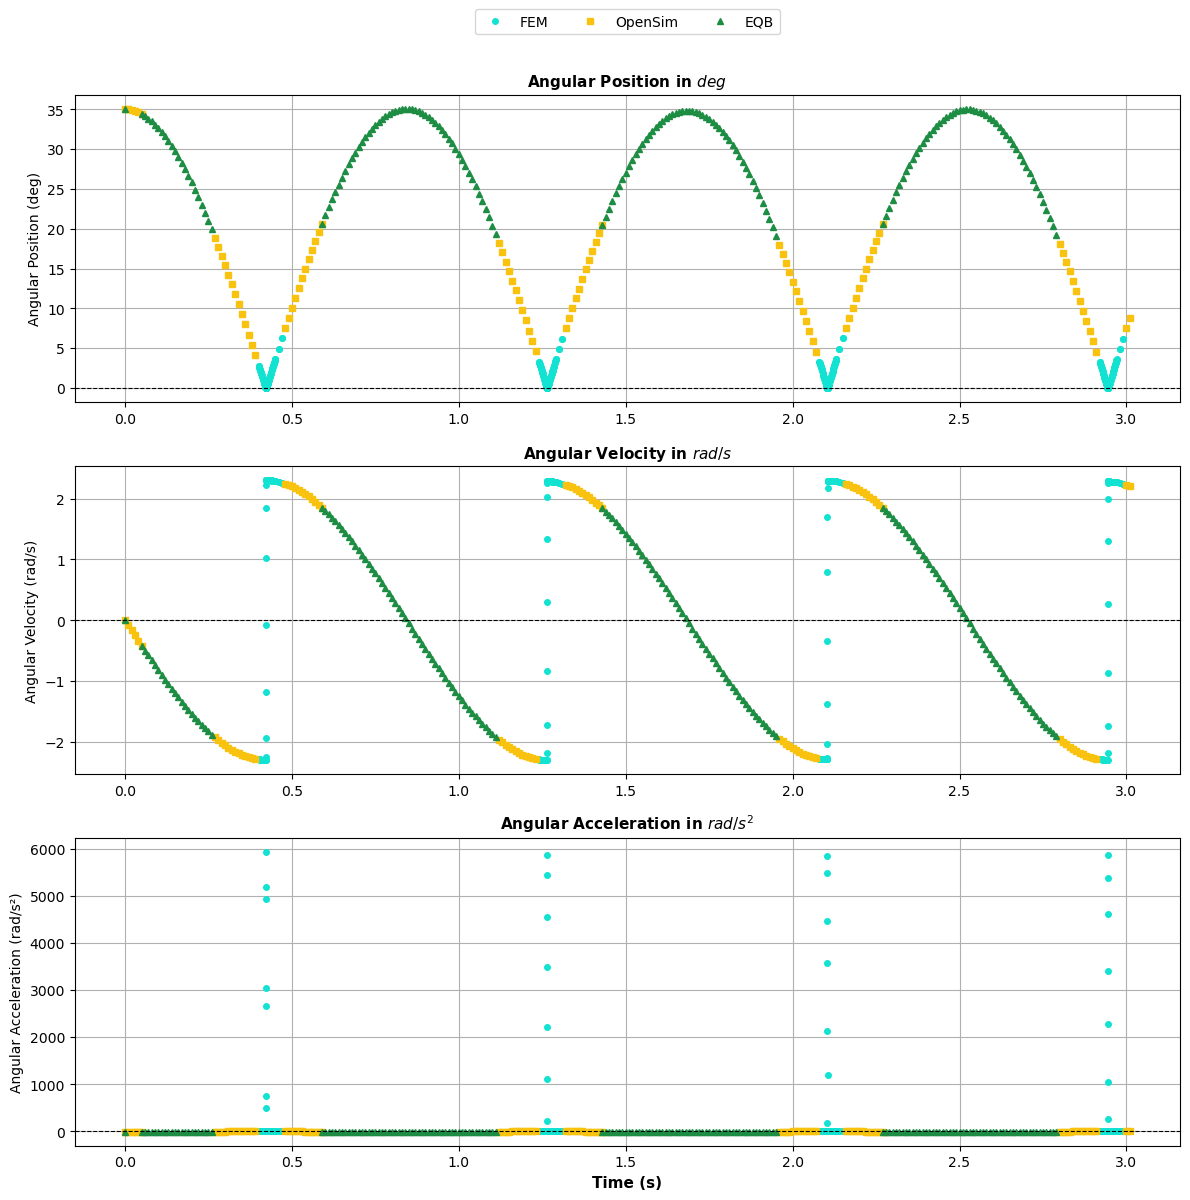

In [6]:
marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5} 
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(12, 12))

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals['FEM'], np.rad2deg(q_vals["FEM"]), label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], np.rad2deg(q_vals["OpenSim"]), label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], np.rad2deg(q_vals["EQB"]), label="EQB", **eqb_style)
#plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals['FEM'], omega_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], omega_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], omega_vals["EQB"], label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
#plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals['FEM'], alpha_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], alpha_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], alpha_vals["EQB"], label="EQB", **eqb_style)
#plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
plt.savefig("../figures/StateSynchronization_impact.svg")
plt.show()